In [1]:
import sys
import git
import pathlib

# Set up the PROJ_ROOT variable
PROJ_ROOT_PATH = pathlib.Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
PROJ_ROOT =  str(PROJ_ROOT_PATH)
if PROJ_ROOT not in sys.path:
    sys.path.append(PROJ_ROOT)

# Explicitly add the current notebook's directory
CURRENT_DIR = str(pathlib.Path().absolute())
if CURRENT_DIR not in sys.path:
    sys.path.insert(0, CURRENT_DIR)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors
%matplotlib inline  

In [3]:
from library.utils import fontstyle, style_map

In [4]:
from collections import defaultdict
import sinter

In [5]:
# Load stim stats

csv_filename = PROJ_ROOT_PATH / "notebooks" / "ler" / "ler_readout.csv"

stats = sinter.read_stats_from_csv_files(csv_filename)
print(f"Loaded {len(stats)} simulation tasks.")

Loaded 30 simulation tasks.


In [6]:
from collections import defaultdict
from itertools import count
from scipy.optimize import curve_fit
import numpy as np

def get_required_distance(target_ler, d_vals, ler_vals):
    # try to find the nearest distance from the experiment results
    try:
        d_req = next(d for (d, ler) in zip(d_vals, ler_vals) if (ler <= target_ler))
    except:
        # derive the distance with the extrapolation (fitting)
        ## fitting
        def exp_decay(d, A, alpha): # NOTE: Use another fitting function if you want
            return A*np.exp(-alpha*d)
        (A_fit, alpha_fit), _ = curve_fit(exp_decay, d_vals, ler_vals)
        # find 
        d_req = next(d for d in count(3,2) if exp_decay(d, A_fit, alpha_fit) <= target_ler)

    return d_req

In [7]:
# input
target_ler = 1e-3

# parsing
grouped = defaultdict(list)
for s in stats:
    md = s.json_metadata
    ms_p = md.get('meas_error')  
    d = md.get('distance')
    ler = float(s.errors / s.shots)
    grouped[ms_p].append((d, ler))

result = []
for ms_p, val_list in sorted(grouped.items()):
    d_list = [d for (d, _) in val_list]
    ler_list = [ler for (_, ler) in val_list]
    d_req = get_required_distance(target_ler, d_list, ler_list)
    pq_per_lq = 2*(d_req**2)-1
    result.append({"meas_error": ms_p, "d_req": d_req, "pq_per_lq": pq_per_lq})

for res in result:
    print(res)

{'meas_error': 0.002, 'd_req': 11, 'pq_per_lq': 241}
{'meas_error': 0.004, 'd_req': 13, 'pq_per_lq': 337}
{'meas_error': 0.008, 'd_req': 13, 'pq_per_lq': 337}
{'meas_error': 0.016, 'd_req': 15, 'pq_per_lq': 449}
{'meas_error': 0.032, 'd_req': 23, 'pq_per_lq': 1057}


In [15]:
grouped

defaultdict(list,
            {0.004: [(11, 0.0010782),
              (13, 0.0004968),
              (15, 0.0002306),
              (17, 0.0001075),
              (19, 4.88e-05),
              (23, 8.1e-06)],
             0.008: [(11, 0.0015),
              (13, 0.0007687),
              (15, 0.0003811),
              (17, 0.0001836),
              (19, 8.82e-05),
              (23, 2.04e-05)],
             0.002: [(11, 0.0008737),
              (13, 0.0003974),
              (15, 0.0001724),
              (17, 7.4e-05),
              (19, 3.08e-05),
              (23, 4.7e-06)],
             0.016: [(11, 0.0028811),
              (13, 0.0016372),
              (15, 0.0009055),
              (17, 0.0004934),
              (19, 0.0002641),
              (23, 8e-05)],
             0.032: [(11, 0.010792219543129406),
              (13, 0.007326),
              (15, 0.0049815),
              (17, 0.0033117),
              (19, 0.0022065),
              (23, 0.0009615)]})

In [8]:
# Get all experiments, their paths and PQs
fridge = "kide"
amps  = ["hemt", "hemt-lp", "hemt-ulp", "sisv1", ]
wires = ["cu", "mn", "ybco"]


exp_name_path = {}
pq_dict = {}
for amp in amps:
    for wire in wires:
        exp = "ff-fc-delft-"+ amp + "_" + wire + "-" + fridge
        fname = PROJ_ROOT_PATH / "notebooks" / "experiments" / fridge / amp / exp / f"{exp}.pkl"
        exp_name_path[exp] = fname
        
        pqfname =  PROJ_ROOT_PATH / "notebooks" / "experiments" / fridge / amp / exp  / f"PQ_{exp}.pkl"
        df_pq =  pd.read_pickle(pqfname)
        pq_dict[exp] = df_pq.iloc[0].tolist()

# For sisv1_11w_mn
exp_name_path['ff-fc-delft-sisv1_11w_mn-kide'] = pathlib.Path('/repos/thermal_scalability/notebooks/experiments/kide/sisv1/ff-fc-delft-sisv1_11w_mn-kide/ff-fc-delft-sisv1_11w_mn-kide.pkl')

pqfname =  pathlib.Path('/repos/thermal_scalability/notebooks/experiments/kide/sisv1/ff-fc-delft-sisv1_11w_mn-kide/PQ_ff-fc-delft-sisv1_11w_mn-kide.pkl')
df_pq =  pd.read_pickle(pqfname)
pq_dict['ff-fc-delft-sisv1_11w_mn-kide'] = df_pq.iloc[0].tolist()


xlabels_dict = {
    'ff-fc-delft-hemt_cu-kide': 'LNF_8G - Cu',
    'ff-fc-delft-hemt_mn-kide': 'LNF_8G - Mn',
    'ff-fc-delft-hemt_ybco-kide': 'LNF_8G - YBCO',
    'ff-fc-delft-hemt-lp_cu-kide': 'LNF_8G (LP) - Cu',
    'ff-fc-delft-hemt-lp_mn-kide': 'LNF_8G (LP) - Mn',
    'ff-fc-delft-hemt-lp_ybco-kide': 'LNF_8G (LP) - YBCO',
    'ff-fc-delft-hemt-ulp_cu-kide': 'ULP-HEMT - Cu',
    'ff-fc-delft-hemt-ulp_mn-kide': 'ULP-HEMT - Mn',
    'ff-fc-delft-hemt-ulp_ybco-kide': 'ULP-HEMT - YBCO',
    'ff-fc-delft-sisv1_cu-kide': 'SIS - Cu',
    'ff-fc-delft-sisv1_mn-kide':'SIS - Mn',
    'ff-fc-delft-sisv1_ybco-kide': 'SIS - YBCO',
    'ff-fc-delft-sisv1_11w_mn-kide':'SIS (11w) - Mn',
}

In [9]:
# Selected experiments to display
exp_list = [
    'ff-fc-delft-hemt_cu-kide',
    'ff-fc-delft-hemt-lp_mn-kide',
    'ff-fc-delft-sisv1_11w_mn-kide',
    'ff-fc-delft-sisv1_ybco-kide',
]

In [10]:
NPQ = {}
for exp in exp_list:
    label = xlabels_dict[exp]
    pq = pq_dict[exp]

    NPQ[label] = min(pq)

In [11]:
meas_error = [res['meas_error'] for res in result]
pq_per_lq = [res['pq_per_lq'] for res in result]
d = [res['d_req'] for res in result]

# NPQ = {
#     "HEMT (Baseline)": 778,
#     "HEMT-HP-Mn": 874,
#     "HEMT-NP-Mn": 1677,
#     "HEMT-LP-Mn": 3899,
#     "HEMT-LP-YBCO": 3961,
#     "SIS-9w-YBCO": 4151,
# }

In [12]:
from library.utils import fontstyle, style_map
title_font, axis_label_font, tick_label_font, legend_font, text_font = fontstyle

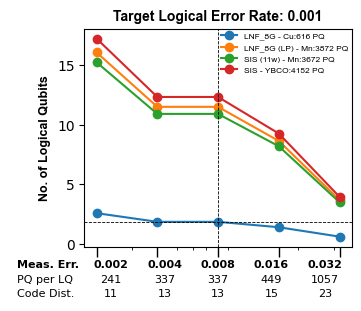

In [13]:
# IEEE TQE Guidelines
# Single column: 3.5" (wide) x 8.5" (height)
# Double column: 7.16" (wide) x 8.5" (height)
fig, ax = plt.subplots(nrows=1, ncols=1, 
                       figsize=(3.5, 3),
                      constrained_layout=True)
# fig.suptitle(f"               Target Logical Error Rate: {target_ler}",fontproperties=title_font)
ax.set_title(f"Target Logical Error Rate: {target_ler}",fontproperties=title_font)
LQ_dict = {}
for label, val in NPQ.items():
    LQ = [val/rate for rate in  pq_per_lq]
    ax.plot(meas_error, LQ, marker='o', label=label)
    LQ_dict[label] = LQ

ax.set_xscale('log')
ax.tick_params(axis='x', which='major', length=7, width=1, direction='out', color='black')
ax.set_xticks(meas_error)
ax.set_xticklabels([])
ax.set_xlabel(None)

# Add a table to the axes
# Table data
data = [meas_error, pq_per_lq, d]
rows = ['Meas. Err.', 'PQ per LQ', 'Code Dist.']

the_table = ax.table(
    cellText=data,
    rowLabels=rows,
    colLabels=None,
    loc='bottom',
    bbox=[0, -0.25, 1, 0.2], # [x0, y0, width, height] relative to axes
    cellLoc='center',
    edges='open',
)
# Adjust font size of the table to fit the small figure
the_table.auto_set_font_size(False)
the_table.set_fontsize(8)


# Bold the first row of the table
# which also serves as the x-ticklabels
for i in range(-1, len(meas_error)):
    cell = the_table[0, i] 
    cell.get_text().set_fontweight('bold')

ax.set_ylabel("No. of Logical Qubits", fontproperties=axis_label_font)

# Rename labels for the legend
handles, labels =  ax.get_legend_handles_labels()

new_labels = []
for label in labels:
    new_label = f"{label}:{NPQ[label]} PQ"
    new_labels.append(new_label)
ax.legend(labels = new_labels,
          ncol=1,
          bbox_to_anchor=(1,1),
          loc='upper right',
          prop=legend_font,
          frameon=False,
          borderaxespad=0.)

ax.axhline(y=LQ_dict['LNF_8G - Cu'][2], color='k', linestyle='--',linewidth=0.6)
ax.axvline(x=0.008, color='k', linestyle='--',linewidth=0.6)

plt.savefig(f"./readout_lq.png",dpi=600)
plt.show()